In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

# Load the EdNet-KT1 dataset (assumed uploaded to Drive)
import pandas as pd

# Replace with your actual path if different
file_path = "/content/drive/MyDrive/Project/Base Papers/Dataset/processed_data_03.csv"
df = pd.read_csv(file_path)

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')

# Filter: remove students with < 5 logs
valid_students = df['student_id'].value_counts()
df = df[df['student_id'].isin(valid_students[valid_students >= 5].index)]

# Sort by student and time
df.sort_values(by=['student_id', 'timestamp'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"✅ Loaded KT1 dataset. Total rows: {len(df)} | Unique students: {df['student_id'].nunique()}")
df.head()


✅ Loaded KT1 dataset. Total rows: 95043160 | Unique students: 685351


,timestamp,problem_id,time_taken,student_id,skill_id,correct,log_delta
0,1970-01-18 23:01:16.233,1,18,1,71,1,0.0
1,1970-01-18 23:01:16.259,2,19,1,44;45;184;181,1,8.0
2,1970-01-18 23:01:16.275,3,11,1,78,1,0.0
3,1970-01-18 23:01:16.302,4,22,1,117,1,16.0
4,1970-01-18 23:01:16.343,5,38,1,74,0,19.0


--- Visualizations of Preprocessing (Engagement Labels) ---

📊 Distribution of Engagement Labels:


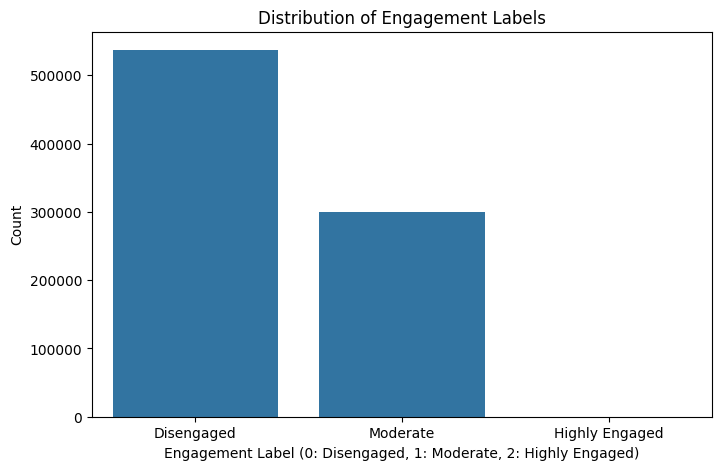


--- End of Preprocessing Visualizations ---


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Visualizations of Preprocessing (Engagement Labels) ---")

# --- Distribution of Engagement Labels (Bar Plot) ---
print("\n📊 Distribution of Engagement Labels:")
plt.figure(figsize=(8, 5))
sns.countplot(x='engagement_label', data=final_df)
plt.title('Distribution of Engagement Labels')
plt.xlabel('Engagement Label (0: Disengaged, 1: Moderate, 2: Highly Engaged)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2], labels=["Disengaged", "Moderate", "Highly Engaged"])
plt.show()

print("\n--- End of Preprocessing Visualizations ---")

In [ ]:
import numpy as np

# Calculate time deltas between logs (per student)
df['log_delta'] = df.groupby('student_id')['timestamp'].diff().dt.total_seconds().fillna(0)

# Create a new session every 30 minutes of inactivity
SESSION_GAP = 120  # 30 minutes in seconds
df['new_session'] = (df['log_delta'] > SESSION_GAP).astype(int)
df['session_id'] = df.groupby('student_id')['new_session'].cumsum()

# Session-level aggregation
features = df.groupby(['student_id', 'session_id']).agg({
    'time_taken': 'mean',
    'correct': 'mean',
    'skill_id': lambda x: (x != x.shift()).sum(),  # skill switches
    'log_delta': ['mean', 'sum'],
    'timestamp': ['min', 'max'],
    'problem_id': 'count'
})

# Flatten column names
features.columns = ['avg_time_taken', 'accuracy', 'skill_switches', 'avg_log_delta',
                    'total_log_delta', 'session_start', 'session_end', 'total_problems']

features.reset_index(inplace=True)

# Derive new features
features['session_duration'] = (features['session_end'] - features['session_start']).dt.total_seconds()
features['burstiness'] = features['total_problems'] / features['session_duration']
features['skill_switch_rate'] = features['skill_switches'] / features['total_problems']

# Drop intermediate timestamp columns
features.drop(columns=['session_start', 'session_end'], inplace=True)

# Save
features.to_csv("session_features.csv", index=False)
print("✅ Feature engineering complete. Saved as session_features.csv")
features.head()


✅ Feature engineering complete. Saved as session_features.csv


,student_id,session_id,avg_time_taken,accuracy,skill_switches,avg_log_delta,total_log_delta,total_problems,session_duration,burstiness,skill_switch_rate
0,1,0,24.250000,0.875000,8,0.029125,0.233,8,0.233,34.334764,1.000000
1,2,0,23.650000,0.375000,39,0.034600,1.384,40,1.384,28.901734,0.975000
2,3,0,26.153846,0.461538,12,0.032692,0.425,13,0.425,30.588235,0.923077
3,4,0,52.571429,0.571429,7,0.055714,0.390,7,0.390,17.948718,1.000000
4,4,1,52.400000,0.600000,5,42.633400,213.167,5,0.207,24.154589,1.000000


--- Visualizations of Engineered Features ---

📊 Distributions of Key Engineered Features:


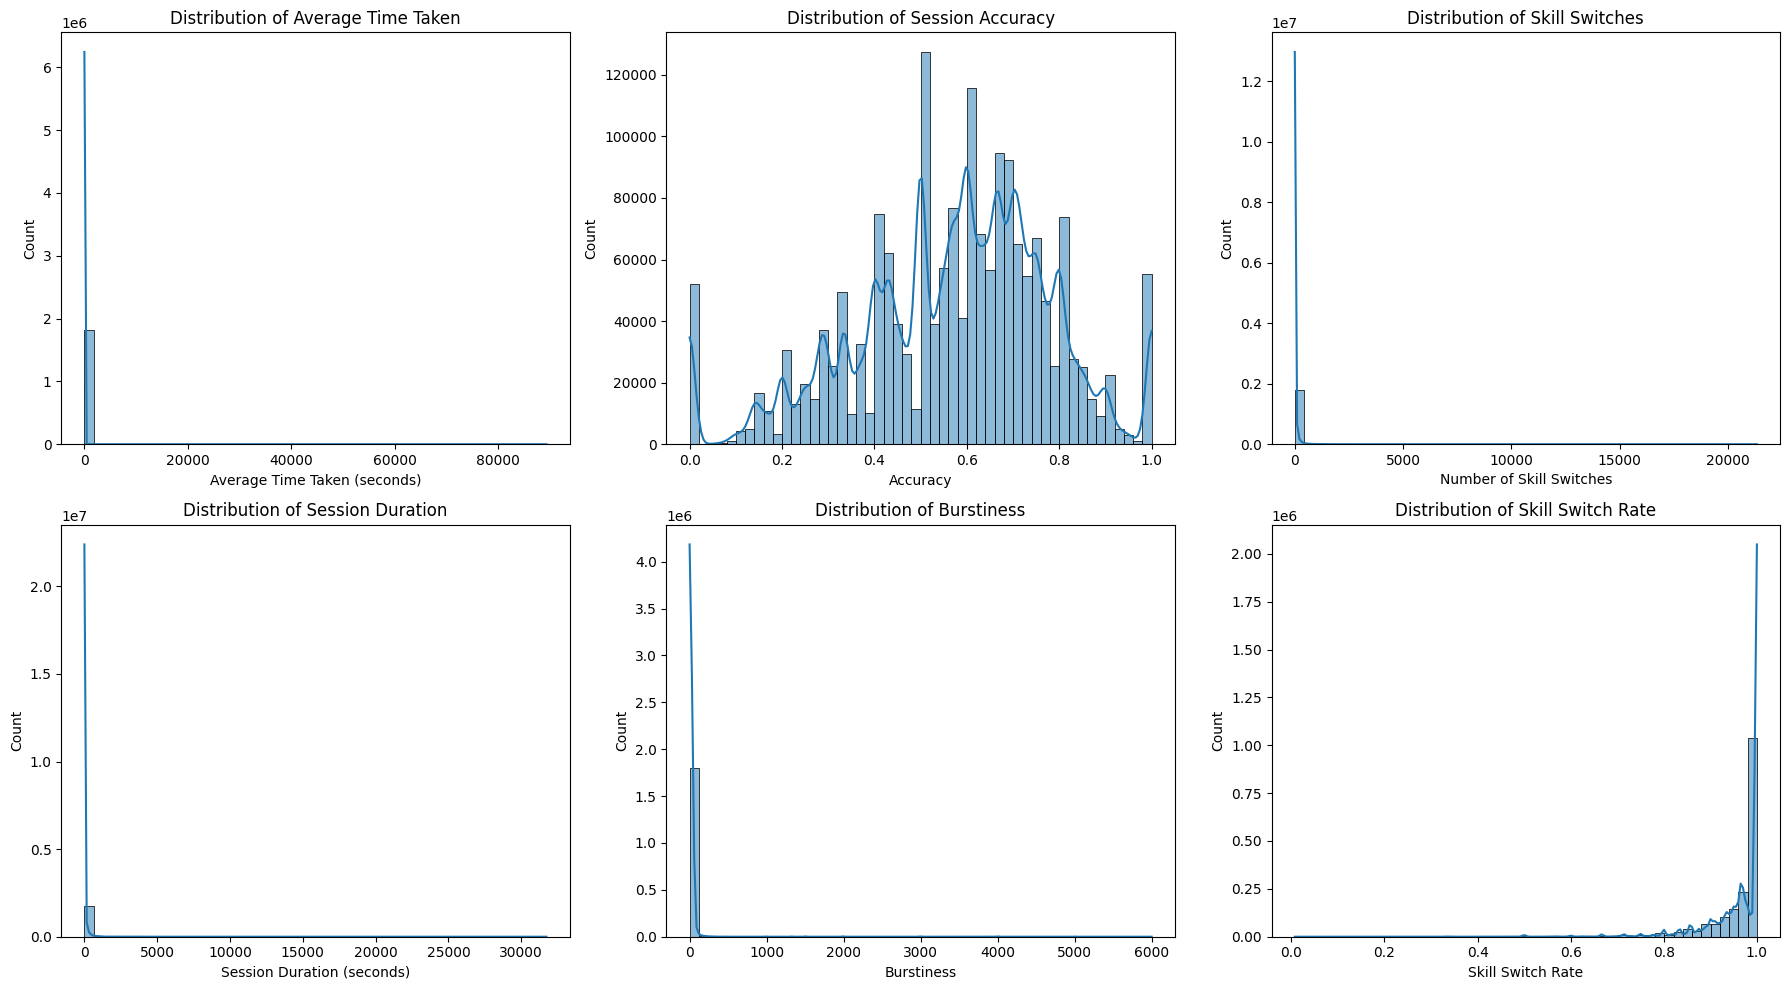


--- End of Feature Engineering Visualizations ---


In [ ]:
import pandas as pd

# Load session features
features = pd.read_csv("session_features.csv")

# Clean up any infinities from burstiness or switch_rate
features['burstiness'] = features['burstiness'].replace([np.inf, -np.inf], 0).fillna(0)
features['skill_switch_rate'] = features['skill_switch_rate'].replace([np.inf, -np.inf], 0).fillna(0)

# Rule-based engagement labeling function
def label_engagement(row):
    if row['accuracy'] >= 0.85 and row['avg_time_taken'] >= 10 and row['skill_switch_rate'] <= 0.25:
        return 2  # Highly engaged
    elif row['accuracy'] >= 0.60 and row['avg_time_taken'] >= 5:
        return 1  # Moderately engaged
    else:
        return 0  # Disengaged

# Apply labels
features['engagement_label'] = features.apply(label_engagement, axis=1)

# Check distribution
print("📊 Label distribution:")
print(features['engagement_label'].value_counts())

# Save labeled dataset
features.to_csv("labeled_session_features.csv", index=False)
print("✅ Engagement labeling complete. Saved as labeled_session_features.csv")

features[['student_id', 'session_id', 'accuracy', 'avg_time_taken', 'skill_switch_rate', 'engagement_label']].head()


📊 Label distribution:
engagement_label
1    920112
0    898203
2        37
Name: count, dtype: int64
✅ Engagement labeling complete. Saved as labeled_session_features.csv


,student_id,session_id,accuracy,avg_time_taken,skill_switch_rate,engagement_label
0,1,0,0.875000,24.250000,1.000000,1
1,2,0,0.375000,23.650000,0.975000,0
2,3,0,0.461538,26.153846,0.923077,0
3,4,0,0.571429,52.571429,1.000000,0
4,4,1,0.600000,52.400000,1.000000,1


from matplotlib import pyplot as plt
_df_0['student_id'].plot(kind='hist', bins=20, title='student_id')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['session_id'].plot(kind='hist', bins=20, title='session_id')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['accuracy'].plot(kind='hist', bins=20, title='accuracy')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['student_id']
  ys = series['engagement_label']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_11.sort_values('student_id', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('student_id')
_ = plt.ylabel('engagement_label')

from matplotlib import pyplot as plt
_df_12['student_id'].plot(kind='line', figsize=(8, 4), title='student_id')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_13['session_id'].plot(kind='line', figsize=(8, 4), title='session_id')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_14['accuracy'].plot(kind='line', figsize=(8, 4), title='accuracy')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_15['avg_time_taken'].plot(kind='line', figsize=(8, 4), title='avg_time_taken')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
!pip install gensim

In [ ]:
import pandas as pd
import numpy as np
from gensim.models import Word2Vec
from tqdm import tqdm
import os

# Load original KT1 log data and labeled sessions
log_df = pd.read_csv(file_path)
log_df['timestamp'] = pd.to_datetime(log_df['timestamp'], unit='ms')

# Load labeled sessions
session_df = pd.read_csv("labeled_session_features.csv")

# Compute session_id again (same logic)
log_df['log_delta'] = log_df.groupby('student_id')['timestamp'].diff().dt.total_seconds().fillna(0)
log_df['new_session'] = (log_df['log_delta'] > 1800).astype(int)
log_df['session_id'] = log_df.groupby('student_id')['new_session'].cumsum()

# Cast skill_id as str
log_df['skill_id'] = log_df['skill_id'].astype(str)

# === Step 1: Build skill_id sequences per session
skill_seqs = log_df.groupby(['student_id', 'session_id'])['skill_id'].apply(list)

# Train Word2Vec on all skill sequences
w2v_model = Word2Vec(sentences=skill_seqs.tolist(), vector_size=16, window=5, min_count=1, sg=1, epochs=10)

# Save model
os.makedirs("output_step4", exist_ok=True)
w2v_model.save("output_step4/skill2vec.model")

# === Step 2: Embed each session sequence
session_embeddings = []

for (student_id, session_id), skill_list in tqdm(skill_seqs.items()):
    vectors = [w2v_model.wv[s] for s in skill_list if s in w2v_model.wv]
    if len(vectors) < 1:
        continue
    mean_vec = np.mean(vectors, axis=0)  # avg pool
    session_embeddings.append({
        "student_id": student_id,
        "session_id": session_id,
        **{f"embed_{i}": val for i, val in enumerate(mean_vec)}
    })

embedding_df = pd.DataFrame(session_embeddings)

# === Step 3: Merge embeddings + features + label
final_df = pd.merge(session_df, embedding_df, on=["student_id", "session_id"], how="inner")

# Save final processed dataset
final_df.to_csv("processed_final_dataset.csv", index=False)
print("✅ Skill2Vec + merge complete. Saved: processed_final_dataset.csv")

final_df.head()


936834it [04:12, 3713.74it/s]


✅ Skill2Vec + merge complete. Saved: processed_final_dataset.csv


,student_id,session_id,avg_time_taken,accuracy,skill_switches,avg_log_delta,total_log_delta,total_problems,session_duration,burstiness,...,embed_6,embed_7,embed_8,embed_9,embed_10,embed_11,embed_12,embed_13,embed_14,embed_15
0,1,0,24.250000,0.875000,8,0.029125,0.233,8,0.233,34.334764,...,-0.031940,0.455558,-0.186579,0.443694,0.047433,-0.157203,0.197113,0.393122,0.067720,-0.174797
1,2,0,23.650000,0.375000,39,0.034600,1.384,40,1.384,28.901734,...,-0.292775,0.699695,0.469170,-0.375590,0.365021,-0.533844,0.247193,0.669732,-0.326992,-0.312832
2,3,0,26.153846,0.461538,12,0.032692,0.425,13,0.425,30.588235,...,-0.870567,0.620190,0.931764,-1.098489,0.908481,-1.083799,0.144595,1.016529,-1.370994,-0.533964
3,4,0,52.571429,0.571429,7,0.055714,0.390,7,0.390,17.948718,...,-0.083750,0.237284,-0.070614,0.541303,0.081469,-0.191521,0.039911,0.585102,-0.166494,-0.028798
4,6,0,16.909091,0.272727,10,0.026818,0.295,11,0.295,37.288136,...,-0.130814,0.465888,-0.319999,0.613868,0.020599,0.044101,0.548783,0.211451,0.087116,-0.273381


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader

# === Load Data
df = pd.read_csv("processed_final_dataset.csv")

# Extract inputs/labels
X = df.drop(columns=['student_id', 'session_id', 'engagement_label']).values.astype(np.float32)
y = df['engagement_label'].values.astype(np.int64)

# Optionally normalize input
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# === Reshape to sequence (e.g., 5 timesteps, 8 features)
X_seq = X.reshape(X.shape[0], 5, -1)

# === Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_seq, y, test_size=0.2, stratify=y, random_state=42)

# === Dataset Class
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

train_loader = DataLoader(SequenceDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(SequenceDataset(X_test, y_test), batch_size=64)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === GRU + Attention Model
class GRUWithAttention(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, output_dim=3, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.attn = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        h_seq, _ = self.gru(x)
        attn_weights = torch.softmax(self.attn(h_seq), dim=1)  # (B, T, 1)
        context = torch.sum(attn_weights * h_seq, dim=1)  # (B, 2H)
        return self.fc(self.dropout(context))

# === Initialize
model = GRUWithAttention(input_dim=X_seq.shape[2]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# === Training Loop
for epoch in range(15):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1:02d} | Loss: {total_loss/len(train_loader):.4f}")

Epoch 01 | Loss: 0.0260
Epoch 02 | Loss: 0.0123
Epoch 03 | Loss: 0.0060
Epoch 04 | Loss: 0.0039
Epoch 05 | Loss: 0.0033
Epoch 06 | Loss: 0.0030
Epoch 07 | Loss: 0.0027
Epoch 08 | Loss: 0.0024
Epoch 09 | Loss: 0.0025
Epoch 10 | Loss: 0.0020
Epoch 11 | Loss: 0.0021
Epoch 12 | Loss: 0.0019
Epoch 13 | Loss: 0.0018
Epoch 14 | Loss: 0.0018
Epoch 15 | Loss: 0.0018


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


✅ Final Accuracy: 0.9996
🎯 Final F1 Score: 0.9996
📊 Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    107368
           1       1.00      1.00      1.00     60024
           2       0.00      0.00      0.00         1

    accuracy                           1.00    167393
   macro avg       0.67      0.67      0.67    167393
weighted avg       1.00      1.00      1.00    167393



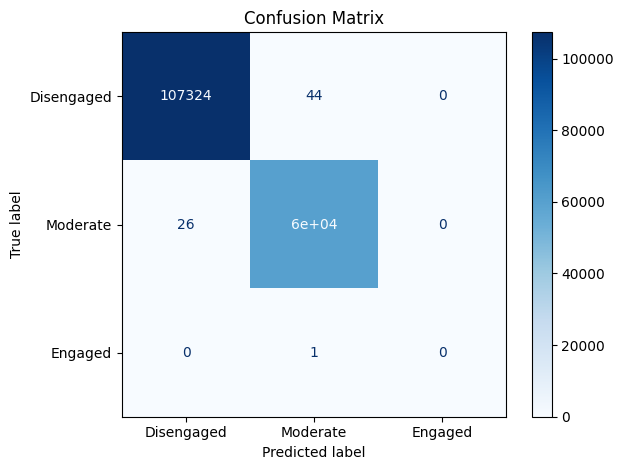

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(yb.numpy())

# Metrics
acc = accuracy_score(all_targets, all_preds)
f1 = f1_score(all_targets, all_preds, average='weighted')
report = classification_report(all_targets, all_preds)
cm = confusion_matrix(all_targets, all_preds)

print(f"✅ Final Accuracy: {acc:.4f}")
print(f"🎯 Final F1 Score: {f1:.4f}")
print("📊 Classification Report:\n", report)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Disengaged", "Moderate", "Engaged"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate training metrics
model.eval()
train_preds = []
train_targets = []

with torch.no_grad():
    for xb, yb in train_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        train_preds.extend(preds)
        train_targets.extend(yb.numpy())

train_acc = accuracy_score(train_targets, train_preds)
train_f1 = f1_score(train_targets, train_preds, average='weighted')

print("--- TRAINING VS. TESTING PERFORMANCE ---")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Training F1 Score: {train_f1:.4f}")
print("-" * 40)
print(f"Testing Accuracy: {acc:.4f}")
print(f"Testing F1 Score: {f1:.4f}")

--- TRAINING VS. TESTING PERFORMANCE ---
Training Accuracy: 0.9996
Training F1 Score: 0.9996
----------------------------------------
Testing Accuracy: 0.9996
Testing F1 Score: 0.9996


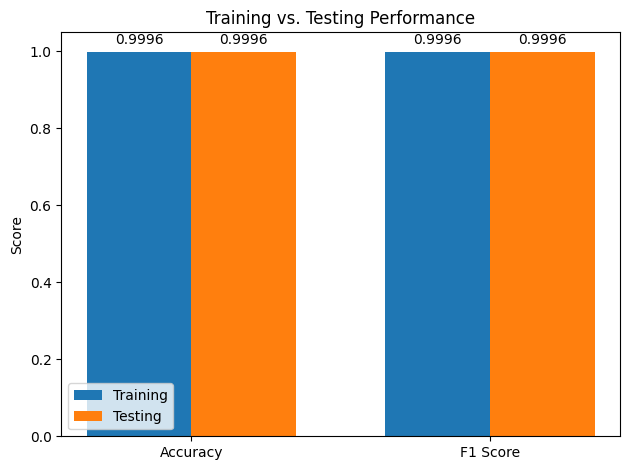

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Accuracy', 'F1 Score']
train_scores = [train_acc, train_f1]
test_scores = [acc, f1]

x = np.arange(len(labels))  # label locations
width = 0.35  # width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, train_scores, width, label='Training')
rects2 = ax.bar(x + width/2, test_scores, width, label='Testing')

# Add some text for labels, titles and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_title('Training vs. Testing Performance')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

In [ ]:
print("--- Original Data (after initial loading and filtering) ---")
print(f"Shape: {df.shape}")
display(df.head())

print("\n--- Session Features ---")
print(f"Shape: {features.shape}")
display(features.head())

print("\n--- Session Embeddings (Skill2Vec) ---")
print(f"Shape: {embedding_df.shape}")
display(embedding_df.head())

print("\n--- Final Processed Dataset (Merged) ---")
print(f"Shape: {final_df.shape}")
display(final_df.head())

--- Original Data (after initial loading and filtering) ---
Shape: (836965, 28)


,student_id,session_id,avg_time_taken,accuracy,skill_switches,avg_log_delta,total_log_delta,total_problems,session_duration,burstiness,...,embed_6,embed_7,embed_8,embed_9,embed_10,embed_11,embed_12,embed_13,embed_14,embed_15
0,1,0,24.250000,0.875000,8,0.029125,0.233,8,0.233,34.334764,...,-0.031940,0.455558,-0.186579,0.443694,0.047433,-0.157203,0.197113,0.393122,0.067720,-0.174797
1,2,0,23.650000,0.375000,39,0.034600,1.384,40,1.384,28.901734,...,-0.292775,0.699695,0.469170,-0.375590,0.365021,-0.533844,0.247193,0.669732,-0.326992,-0.312832
2,3,0,26.153846,0.461538,12,0.032692,0.425,13,0.425,30.588235,...,-0.870567,0.620190,0.931764,-1.098489,0.908481,-1.083800,0.144595,1.016529,-1.370994,-0.533964
3,4,0,52.571429,0.571429,7,0.055714,0.390,7,0.390,17.948718,...,-0.083750,0.237284,-0.070614,0.541303,0.081469,-0.191521,0.039911,0.585102,-0.166494,-0.028798
4,6,0,16.909091,0.272727,10,0.026818,0.295,11,0.295,37.288136,...,-0.130814,0.465888,-0.319999,0.613868,0.020599,0.044101,0.548783,0.211451,0.087116,-0.273381



--- Session Features ---
Shape: (1818352, 12)


,student_id,session_id,avg_time_taken,accuracy,skill_switches,avg_log_delta,total_log_delta,total_problems,session_duration,burstiness,skill_switch_rate,engagement_label
0,1,0,24.250000,0.875000,8,0.029125,0.233,8,0.233,34.334764,1.000000,1
1,2,0,23.650000,0.375000,39,0.034600,1.384,40,1.384,28.901734,0.975000,0
2,3,0,26.153846,0.461538,12,0.032692,0.425,13,0.425,30.588235,0.923077,0
3,4,0,52.571429,0.571429,7,0.055714,0.390,7,0.390,17.948718,1.000000,0
4,4,1,52.400000,0.600000,5,42.633400,213.167,5,0.207,24.154589,1.000000,1



--- Session Embeddings (Skill2Vec) ---
Shape: (936834, 18)


,student_id,session_id,embed_0,embed_1,embed_2,embed_3,embed_4,embed_5,embed_6,embed_7,embed_8,embed_9,embed_10,embed_11,embed_12,embed_13,embed_14,embed_15
0,1,0,0.259019,0.786785,-0.452201,-0.066789,-0.352960,0.315134,-0.031940,0.455558,-0.186579,0.443694,0.047433,-0.157203,0.197113,0.393122,0.067720,-0.174797
1,2,0,0.343679,1.231576,-0.549781,-0.324547,0.189765,0.616702,-0.292775,0.699695,0.469170,-0.375590,0.365021,-0.533844,0.247193,0.669732,-0.326992,-0.312832
2,3,0,0.040735,1.309600,-0.572838,-0.671070,0.298370,0.118063,-0.870567,0.620190,0.931764,-1.098489,0.908481,-1.083799,0.144595,1.016529,-1.370994,-0.533964
3,4,0,0.202786,0.868187,-0.322975,0.034237,-0.304177,0.500057,-0.083750,0.237284,-0.070614,0.541303,0.081469,-0.191521,0.039911,0.585102,-0.166494,-0.028798
4,5,0,0.385504,0.795646,-0.798441,0.128111,-0.493418,0.374393,0.027968,0.623471,-0.563327,0.535556,-0.128557,0.091205,-0.018098,0.249779,0.194622,0.000638



--- Final Processed Dataset (Merged) ---
Shape: (836965, 28)


,student_id,session_id,avg_time_taken,accuracy,skill_switches,avg_log_delta,total_log_delta,total_problems,session_duration,burstiness,...,embed_6,embed_7,embed_8,embed_9,embed_10,embed_11,embed_12,embed_13,embed_14,embed_15
0,1,0,24.250000,0.875000,8,0.029125,0.233,8,0.233,34.334764,...,-0.031940,0.455558,-0.186579,0.443694,0.047433,-0.157203,0.197113,0.393122,0.067720,-0.174797
1,2,0,23.650000,0.375000,39,0.034600,1.384,40,1.384,28.901734,...,-0.292775,0.699695,0.469170,-0.375590,0.365021,-0.533844,0.247193,0.669732,-0.326992,-0.312832
2,3,0,26.153846,0.461538,12,0.032692,0.425,13,0.425,30.588235,...,-0.870567,0.620190,0.931764,-1.098489,0.908481,-1.083799,0.144595,1.016529,-1.370994,-0.533964
3,4,0,52.571429,0.571429,7,0.055714,0.390,7,0.390,17.948718,...,-0.083750,0.237284,-0.070614,0.541303,0.081469,-0.191521,0.039911,0.585102,-0.166494,-0.028798
4,6,0,16.909091,0.272727,10,0.026818,0.295,11,0.295,37.288136,...,-0.130814,0.465888,-0.319999,0.613868,0.020599,0.044101,0.548783,0.211451,0.087116,-0.273381


--- Additional Visualizations of Preprocessed Data ---

📊 Distribution of Engagement Labels:


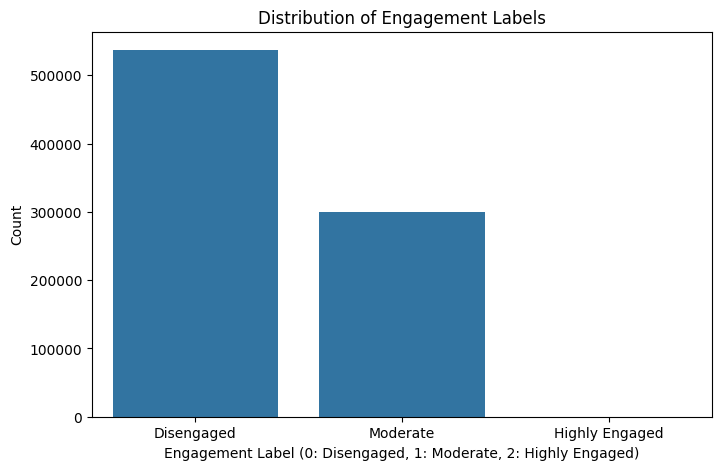


📈 Relationship between Accuracy and Engagement:


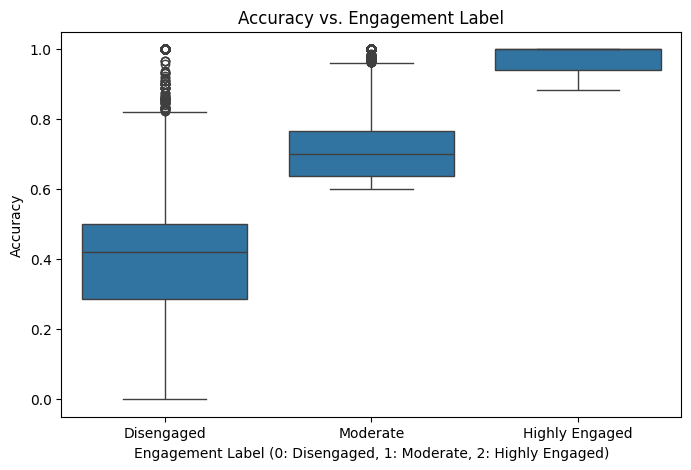


⏱️ Relationship between Average Time Taken and Engagement:


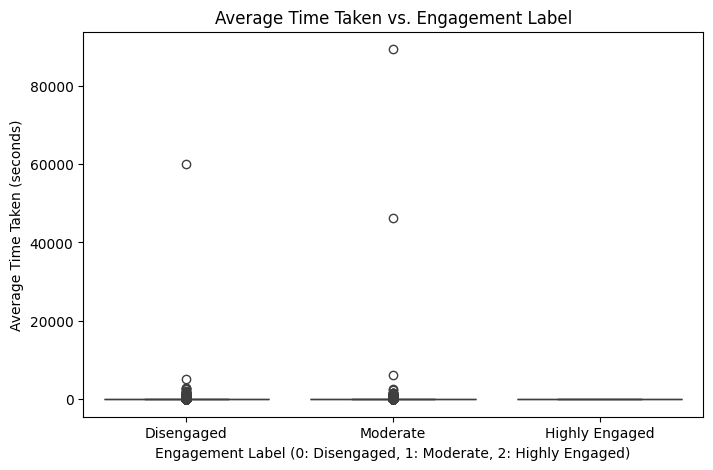


--- End of Additional Visualizations ---


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Additional Visualizations of Preprocessed Data ---")

# --- Distribution of Engagement Labels ---
print("\n📊 Distribution of Engagement Labels:")
plt.figure(figsize=(8, 5))
sns.countplot(x='engagement_label', data=final_df)
plt.title('Distribution of Engagement Labels')
plt.xlabel('Engagement Label (0: Disengaged, 1: Moderate, 2: Highly Engaged)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2], labels=["Disengaged", "Moderate", "Highly Engaged"])
plt.show()

# --- Relationship between Features and Engagement (Example: Accuracy vs. Engagement) ---
print("\n📈 Relationship between Accuracy and Engagement:")
plt.figure(figsize=(8, 5))
sns.boxplot(x='engagement_label', y='accuracy', data=final_df)
plt.title('Accuracy vs. Engagement Label')
plt.xlabel('Engagement Label (0: Disengaged, 1: Moderate, 2: Highly Engaged)')
plt.ylabel('Accuracy')
plt.xticks(ticks=[0, 1, 2], labels=["Disengaged", "Moderate", "Highly Engaged"])
plt.show()

# --- Relationship between Features and Engagement (Example: Average Time Taken vs. Engagement) ---
print("\n⏱️ Relationship between Average Time Taken and Engagement:")
plt.figure(figsize=(8, 5))
sns.boxplot(x='engagement_label', y='avg_time_taken', data=final_df)
plt.title('Average Time Taken vs. Engagement Label')
plt.xlabel('Engagement Label (0: Disengaged, 1: Moderate, 2: Highly Engaged)')
plt.ylabel('Average Time Taken (seconds)')
plt.xticks(ticks=[0, 1, 2], labels=["Disengaged", "Moderate", "Highly Engaged"])
plt.show()

print("\n--- End of Additional Visualizations ---")

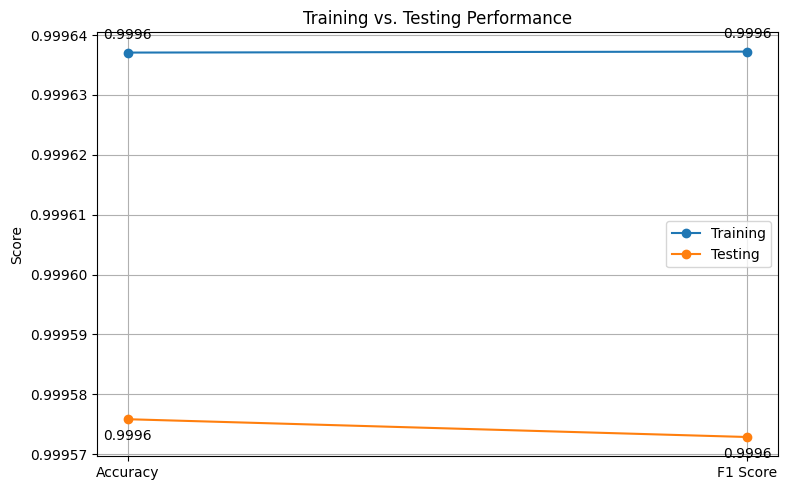

## Project Implementation Process

Here is an outline of the project implementation process:

1.  **Data Loading**: Load the raw log data from the specified file path.
2.  **Initial Data Cleaning and Filtering**:
    *   Convert timestamp to datetime objects.
    *   Filter out students with fewer than a specified minimum number of logs.
    *   Sort data by student and timestamp.
3.  **Feature Engineering (Session-Level)**:
    *   Calculate time deltas between consecutive logs for each student.
    *   Define sessions based on periods of inactivity (e.g., > 30 minutes).
    *   Aggregate features at the session level (e.g., mean time taken, accuracy, total problems, skill switches).
    *   Derive additional features like session duration, burstiness, and skill switch rate.
    *   Clean up infinite or NaN values in the derived features.
4.  **Engagement Labeling**:
    *   Apply a rule-based function to assign engagement labels (Disengaged, Moderate, Highly Engaged) to each session based on features like accuracy, average time taken, and skill switch rate.
5.  **Skill Embedding (Skill2Vec)**:
    *   Re-compute session IDs on the original log data based on a potentially different session gap (as done in the code).
    *   Extract skill ID sequences for each session.
    *   Train a Word2Vec model on the skill ID sequences to learn skill embeddings.
    *   Embed each session sequence by aggregating the vectors of the skills within that session (e.g., using mean pooling).
6.  **Data Merging**:
    *   Merge the session-level features, engagement labels, and skill embeddings into a single final dataset.
7.  **Model Preparation**:
    *   Separate features (X) and labels (y) from the final dataset.
    *   Optionally normalize the features.
    *   Reshape the data into sequences suitable for the GRU model (if applicable, based on the model input requirements).
    *   Split the data into training and testing sets.
    *   Create PyTorch Dataset and DataLoader objects for efficient batching during training and evaluation.
8.  **Model Definition and Initialization**:
    *   Define the GRU with Attention model architecture.
    *   Initialize the model, loss function (CrossEntropyLoss), and optimizer (Adam).
9.  **Model Training**:
    *   Train the model on the training data for a specified number of epochs, including forward pass, loss calculation, backward pass, and optimizer step.
10. **Model Evaluation**:
    *   Evaluate the trained model on the testing data.
    *   Calculate performance metrics such as accuracy, F1 score, precision, and recall.
    *   Generate a classification report and confusion matrix.
11. **Performance Visualization**:
    *   Generate graphs to compare training and testing performance metrics.
    *   Visualize the confusion matrix.
12. **Finish task**: The task is complete.

In [ ]:
import pandas as pd

# Create a dictionary with the metrics
metrics_data = {
    'Metric': ['Accuracy', 'F1 Score'],
    'Training': [train_acc, train_f1],
    'Testing': [acc, f1]
}

# Create a pandas DataFrame
metrics_df = pd.DataFrame(metrics_data)

# Display the DataFrame as a table
print("📊 Model Performance Table:")
display(metrics_df)

📊 Model Performance Table:


,Metric,Training,Testing
0,Accuracy,0.999637,0.999576
1,F1 Score,0.999637,0.999573
